In [6]:
from frumkin.electrolyte import LatticeElectrolyte, Ion, Water
from frumkin.gongadze_iglic import GongadzeIglic
import numpy as np 
from scipy import constants as C 

PZC_SHE = 0.0
RHE_SHIFT = 59e-3

def get_model(conc, cation_size=6, ohp=4, min_eps=5):
    el = LatticeElectrolyte([
        Water(min_eps=min_eps),
        Ion(name=r"Na$^+$", size=cation_size, concentration=conc, charge=+1),
        Ion(name=r"Cl$^-$", size=2, concentration=conc, charge=-1),
    ])
    model = GongadzeIglic(el, ohp=ohp)
    return model

def fbv(potential_she, conc, cation_size=6, ohp=4, min_eps=5, xprime=3):
    phi0 = potential_she - PZC_SHE 

    model = get_model(conc, cation_size, ohp, min_eps)
    result = model.voltammetry(phi0)

    phi2 = phi0 - result.electric_field * xprime 
    beta_e0 = C.elementary_charge / (C.Boltzmann * 298)  # e0/kbT
    alpha = 0.5
    return -np.exp(-beta_e0 * alpha * (phi0 - phi2))

concentrations = [10e-3, 50e-3, 100e-3]
ph_values = [11, 12, 13]
potential_rhe = np.linspace(-0.2, np.max(ph_values) * RHE_SHIFT + PZC_SHE, 100)

Sweep from -3.31e+01 to 4.60e+00, starting at 0.00e+00. Maximum relative residual: 3.488e-05.
Sweep from -3.31e+01 to 4.60e+00, starting at 0.00e+00. Maximum relative residual: 3.628e-05.
Sweep from -3.31e+01 to 4.60e+00, starting at 0.00e+00. Maximum relative residual: 3.320e-05.


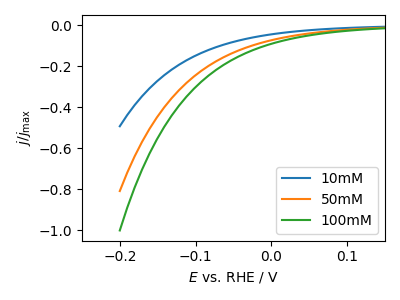

In [7]:
import matplotlib.pyplot as plt 
%matplotlib widget 

ACIDITY = 11 

fig = plt.figure(figsize=(4, 3))
ax = fig.add_subplot()

currents = [] 

for c in concentrations: 
    potential_she = potential_rhe - RHE_SHIFT * ACIDITY 
    i = fbv(potential_she, c)
    currents.append(i) 

for c, i in zip(concentrations, currents):
    ax.plot(potential_rhe, i / np.max(np.abs(currents)), label=f"{c*1e3:.0f}mM")

ax.legend()
ax.set_xlim([-0.25, 0.15])
ax.set_ylabel(r"$j/j_\mathrm{max}$")
ax.set_xlabel(r"$E$ vs. RHE / V")

fig.tight_layout()